## Importar datos

In [ ]:
import pandas as pd
import re
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Sport car price.csv")

In [ ]:
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


## Revisión detalles básicos del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


## Tratamiento de nulls

In [ ]:
print("Cantidad de filas con algún null:", df.isna().any(axis=1).sum())

Cantidad de filas con algún null: 12


In [ ]:
df[df.isna().any(axis=1)]

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
168,Rimac,C_Two,2022,NaN,1914,1696,1.9,"2,400,000"
171,Tesla,Model S Plaid,2021,NaN,1020,1050,1.98,"131,190"
222,Porsche,Taycan Turbo S,2021,NaN,750,774,2.6,"185,000"
247,Tesla,Model S Plaid,2022,NaN,1020,1050,1.9,"131,190"
387,Rimac,C_Two,2022,NaN,1888,1696,1.8,"2,400,000"
389,Tesla,Roadster,2022,NaN,10000+,0,1.9,"200,000"
642,Tesla,Model S Plaid,2021,Electric,1020,NaN,1.9,"139,990"
686,Rimac,C_Two,2022,NaN,1914,1696,1.85,"2,400,000"
697,Lotus,Evija,2022,NaN,1972,1254,2.5,"2,700,000"
752,Porsche,Taycan,2022,NaN,469,479,3.8,"79,900"


In [ ]:
# 1. Rellenar la fila con algún valor imputado.
df["Engine Size (L)"] = df["Engine Size (L)"].fillna("0")
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


In [ ]:
# 2. Eliminar las filas con nulas
#df = df[~df.isna().any(axis=1)]
df = df.dropna(axis=0)
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


In [ ]:
print("Cantidad de filas con algún null:", df.isna().any(axis=1).sum())

Cantidad de filas con algún null: 0


## Revisión de duplicados

In [ ]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())

Cantidad de filas duplicadas: 288


In [ ]:
# Revisar cuáles son las que están duplicadas
df[df.duplicated(keep=False)]

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
993,Audi,RS 5,2021,2.9,444,443,3.5,"75,100"
997,Chevrolet,Camaro,2021,6.2,455,455,4,"25,000"
1000,Aston Martin,Vantage,2021,4,503,505,3.6,"146,000"
1001,Bugatti,Chiron,2021,8,1479,1180,2.4,"3,000,000"


In [ ]:
df = df.drop_duplicates()
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
999,Nissan,370Z,2021,3.7,332,270,5.1,"30,090"
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


In [ ]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())

Cantidad de filas duplicadas: 0


## Renombrar columnas a un estándar

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df = df.rename(columns={
    "Engine Size (L)": "Engine Size",
    "Torque (lb-ft)": "Torque",
    "Price (in USD)": "Price",
    "0-60 MPH Time (seconds)": "Speed"
})
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
711,Nissan,370Z,2021,3.7,332,270,5.1,"30,090"
712,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
713,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
714,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


## Feature Engineering

In [ ]:
# Intentar cambiar tipo de dato a columnas que deberían ser numéricas
for col in ["Engine Size", "Horsepower", "Torque", "Speed", "Price"]:
  try:
    df[col].astype(float)
    print("SUCCESS: Sí se puede transformar la columna", col)
  except Exception as e:
    print("ERROR: Columna", col, "no es numérica", e)

ERROR: Columna Engine Size no es numérica could not convert string to float: 'Electric'
ERROR: Columna Horsepower no es numérica could not convert string to float: '1000+'
ERROR: Columna Torque no es numérica could not convert string to float: '-'
ERROR: Columna Speed no es numérica could not convert string to float: '< 1.9'
ERROR: Columna Price no es numérica could not convert string to float: '101,200'


In [ ]:
def assign_engine_type(x):
  if(x["Engine Size"] == "0" or
     "Electric" in x["Engine Size"]
     or x["Car Make"] == "Tesla"
    ):
    return "Electric Motor"
  else:
    return "Gas Motor"

In [ ]:
df["Engine Type"] = df.apply(assign_engine_type, axis=1)
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type
0,Porsche,911,2022,3,379,331,4,"101,200",Gas Motor
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390",Gas Motor
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750",Gas Motor
3,Audi,R8,2022,5.2,562,406,3.2,"142,700",Gas Motor
4,McLaren,720S,2021,4,710,568,2.7,"298,000",Gas Motor
...,...,...,...,...,...,...,...,...,...
711,Nissan,370Z,2021,3.7,332,270,5.1,"30,090",Gas Motor
712,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000",Gas Motor
713,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000",Electric Motor
714,Pagani,Huayra,2021,6,764,738,3,"2,600,000",Gas Motor


In [ ]:
df["Engine Size"] = df.apply(lambda x: "0" if (x["Engine Type"] == "Electric Motor") else x["Engine Size"], axis=1)
# Eliminar Hybrids
df["Engine Size"] = df["Engine Size"].apply(lambda x: re.sub("[^0-9.]", "", x))
# Rellenar cadenas vacías "" con 0
df["Engine Size"] = df["Engine Size"].apply(lambda x: "0" if x == "" else x)
# Castear a float
df["Engine Size"] = df["Engine Size"].astype(float)
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type
0,Porsche,911,2022,3.0,379,331,4,"101,200",Gas Motor
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390",Gas Motor
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750",Gas Motor
3,Audi,R8,2022,5.2,562,406,3.2,"142,700",Gas Motor
4,McLaren,720S,2021,4.0,710,568,2.7,"298,000",Gas Motor
...,...,...,...,...,...,...,...,...,...
711,Nissan,370Z,2021,3.7,332,270,5.1,"30,090",Gas Motor
712,Koenigsegg,Jesko,2022,5.0,1280,1106,2.5,"3,000,000",Gas Motor
713,Lotus,Evija,2021,0.0,1972,1254,2,"2,000,000",Electric Motor
714,Pagani,Huayra,2021,6.0,764,738,3,"2,600,000",Gas Motor


In [ ]:
df[df.duplicated()]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type
263,Porsche,Taycan Turbo S,2021,0.0,750,774,2.6,"185,000",Electric Motor
434,Rimac,C_Two,2022,0.0,1914,1696,1.9,"2,400,000",Electric Motor
630,Ferrari,SF90 Stradale,2021,4.0,986,590,2.5,"625,000",Gas Motor


In [ ]:
df["Horsepower"] = df["Horsepower"].apply(lambda x: re.sub("[^0-9.]", "", x)).astype(float)

In [ ]:
df["Torque"] = df["Torque"].apply(lambda x: re.sub("[^0-9.]", "", x))
df["Torque"] = df["Torque"].apply(lambda x: "0" if x == "" else x)
df["Torque"] = df["Torque"].astype(float)

In [ ]:
df["Speed"] = df["Speed"].apply(lambda x: re.sub("[^0-9.]", "", x)).astype(float)

In [ ]:
df["Price"] = df["Price"].apply(lambda x: x.replace(",", "")).astype(float)

In [ ]:
df["Antiquity"] = datetime.date.today().year - df["Year"]

In [ ]:
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type,Antiquity
0,Porsche,911,2022,3.0,379.0,331.0,4.00,101200.0,Gas Motor,3
1,Lamborghini,Huracan,2021,5.2,630.0,443.0,2.80,274390.0,Gas Motor,4
2,Ferrari,488 GTB,2022,3.9,661.0,561.0,3.00,333750.0,Gas Motor,3
3,Audi,R8,2022,5.2,562.0,406.0,3.20,142700.0,Gas Motor,3
4,McLaren,720S,2021,4.0,710.0,568.0,2.70,298000.0,Gas Motor,4
...,...,...,...,...,...,...,...,...,...,...
711,Nissan,370Z,2021,3.7,332.0,270.0,5.10,30090.0,Gas Motor,4
712,Koenigsegg,Jesko,2022,5.0,1280.0,1106.0,2.50,3000000.0,Gas Motor,3
713,Lotus,Evija,2021,0.0,1972.0,1254.0,2.00,2000000.0,Electric Motor,4
714,Pagani,Huayra,2021,6.0,764.0,738.0,3.00,2600000.0,Gas Motor,4


## EDA (Análisis Exploratorio de la Data)

### Estadísticas y gráfica básicas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Car Make     716 non-null    object 
 1   Car Model    716 non-null    object 
 2   Year         716 non-null    int64  
 3   Engine Size  716 non-null    float64
 4   Horsepower   716 non-null    float64
 5   Torque       716 non-null    float64
 6   Speed        716 non-null    float64
 7   Price        716 non-null    float64
 8   Engine Type  716 non-null    object 
 9   Antiquity    716 non-null    int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 56.1+ KB


In [ ]:
df.describe()

,Year,Engine Size,Horsepower,Torque,Speed,Price,Antiquity
count,716.000000,716.000000,716.000000,716.000000,716.00000,7.160000e+02,716.000000
mean,2021.159218,4.124162,653.250000,570.061453,3.55852,3.909350e+05,3.840782
std,2.334254,1.786019,586.968543,507.113812,0.80271,7.766644e+05,2.334254
min,1965.000000,0.000000,181.000000,0.000000,1.80000,2.500000e+04,2.000000
25%,2021.000000,3.000000,454.000000,398.000000,3.00000,7.010000e+04,3.000000
50%,2021.000000,4.000000,591.000000,505.000000,3.50000,1.329225e+05,4.000000
75%,2022.000000,5.200000,710.000000,627.000000,4.00000,2.257500e+05,4.000000
max,2023.000000,8.400000,10000.000000,10000.000000,6.50000,5.200000e+06,60.000000


<Axes: xlabel='Car Make'>

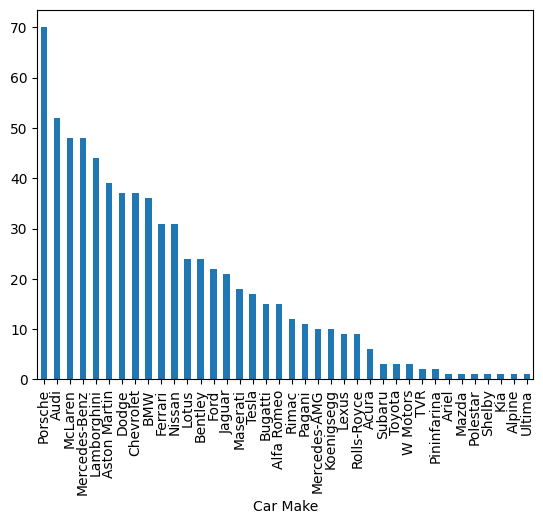

In [ ]:
df["Car Make"].value_counts().plot(kind="bar")

In [ ]:
# Homologar nombres de fabricantes
def homologar_fabricantes(x):
  if "mercedes" in x.lower():
    return "Mercedes"
  if "audi" in x.lower():
    "Audi"
  return x


<Axes: xlabel='Car Make'>

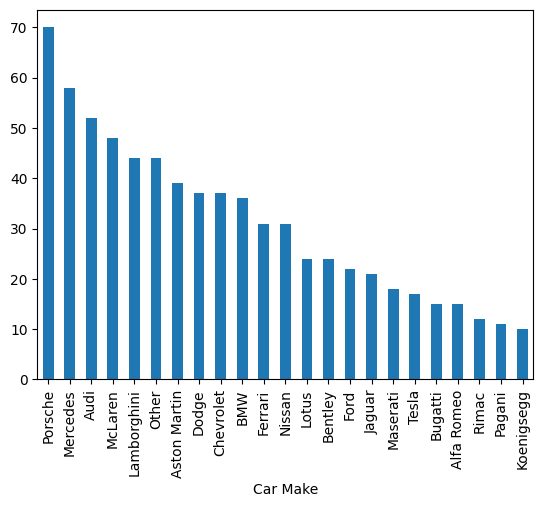

In [ ]:
# Homologar categorías
df["Car Make"] = df["Car Make"].apply(homologar_fabricantes)
# Agrupar en otros
maker_counts = df["Car Make"].value_counts()
df["Car Make"] = df["Car Make"].apply(lambda x: "Other" if maker_counts[x] < 10 else x)
# Imprimir resultado
df["Car Make"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

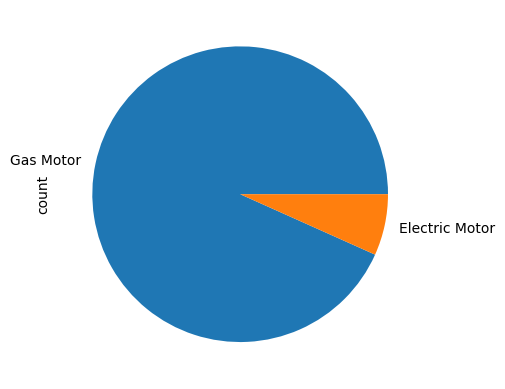

In [ ]:
df["Engine Type"].value_counts().plot(kind="pie")

<Axes: >

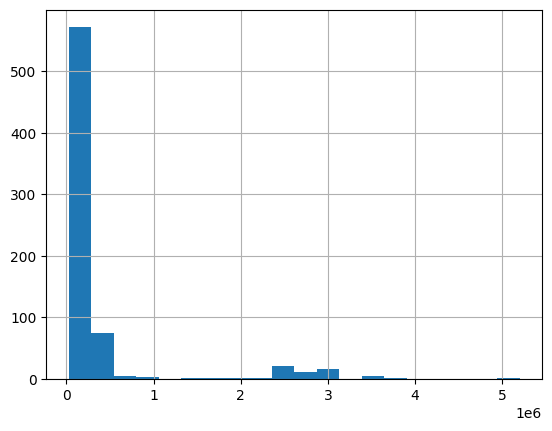

In [ ]:
df["Price"].hist(bins=20)

<Axes: >

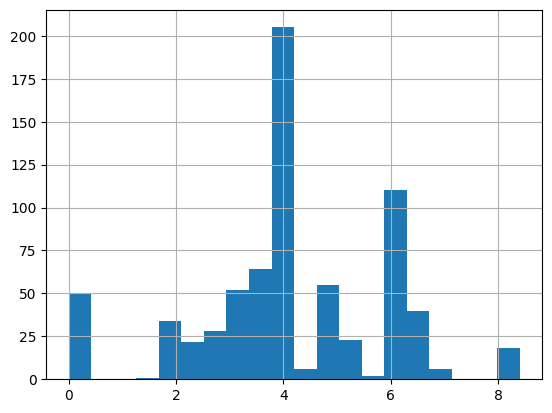

In [ ]:
df["Engine Size"].hist(bins=20)

<Axes: >

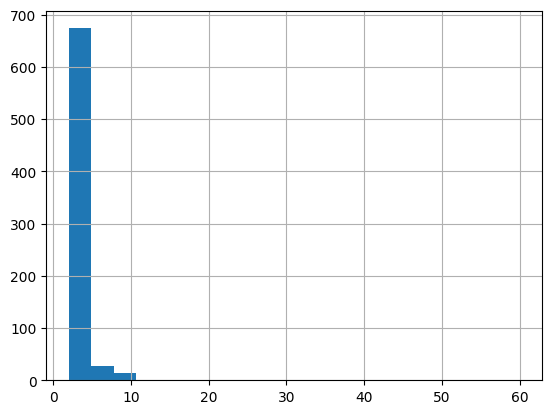

In [ ]:
df["Antiquity"].hist(bins=20)

### Interacciones entre variables

<Axes: xlabel='Car Make', ylabel='Price'>

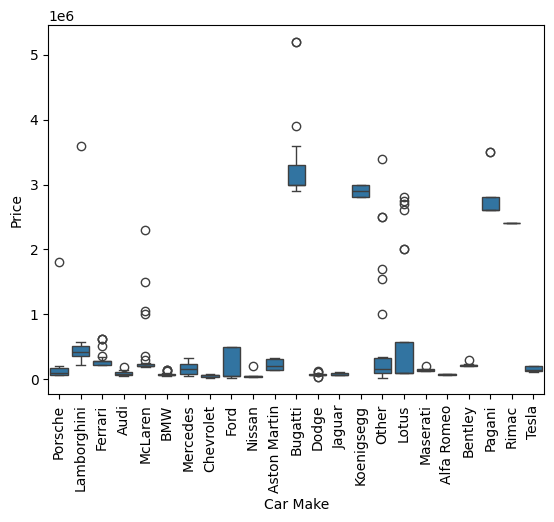

In [ ]:
# Categóricas-numéricas boxplots

plt.xticks(rotation=90)
sns.boxplot(x="Car Make", y="Price", data=df)

<Axes: xlabel='Engine Type', ylabel='Price'>

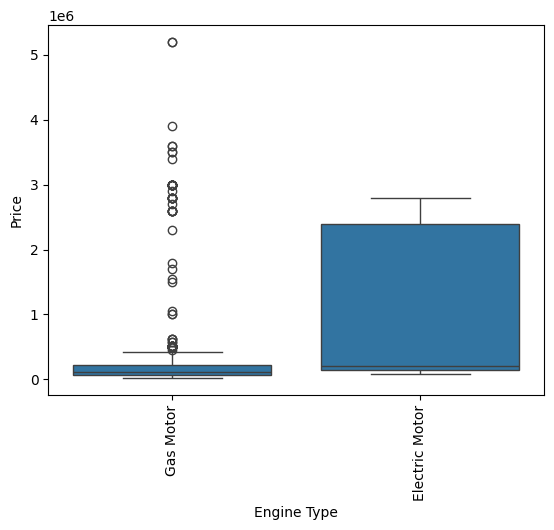

In [ ]:
plt.xticks(rotation=90)
sns.boxplot(x="Engine Type", y="Price", data=df)

<Axes: xlabel='Antiquity', ylabel='Price'>

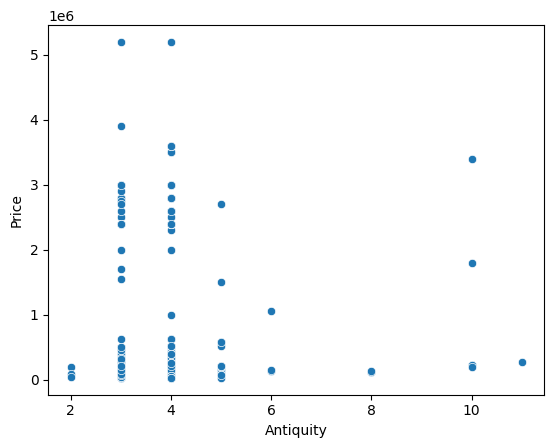

In [ ]:
# Númericas-numéricas scatterplots
df_without_antiquity_outlier = df[df["Antiquity"] < 20]
sns.scatterplot(x="Antiquity", y="Price", data=df_without_antiquity_outlier)

<Axes: xlabel='Speed', ylabel='Price'>

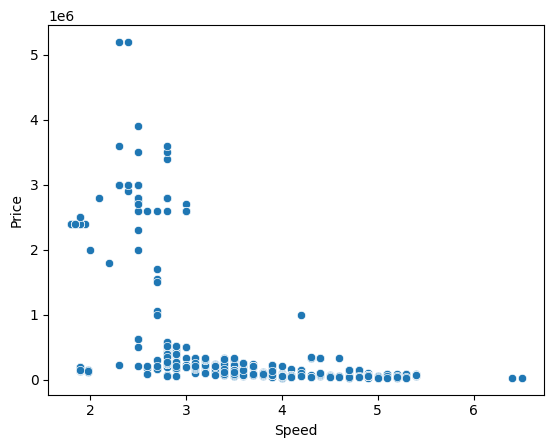

In [ ]:
# Númericas-numéricas scatterplots
sns.scatterplot(x="Speed", y="Price", data=df)

<Axes: xlabel='Horsepower', ylabel='Price'>

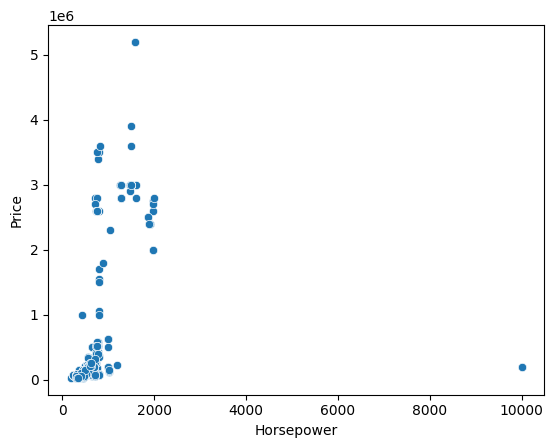

In [ ]:
# Númericas-numéricas scatterplots
sns.scatterplot(x="Horsepower", y="Price", data=df)

In [ ]:
# Correlaciones

df.select_dtypes(include="number").corr()

,Year,Engine Size,Horsepower,Torque,Speed,Price,Antiquity
Year,1.000000,-0.155813,0.031871,0.031811,-0.015564,-0.040912,-1.000000
Engine Size,-0.155813,1.000000,-0.106886,-0.112040,-0.022762,0.124412,0.155813
Horsepower,0.031871,-0.106886,1.000000,0.549410,-0.486662,0.406444,-0.031871
Torque,0.031811,-0.112040,0.549410,1.000000,-0.450314,0.355289,-0.031811
Speed,-0.015564,-0.022762,-0.486662,-0.450314,1.000000,-0.498374,0.015564
Price,-0.040912,0.124412,0.406444,0.355289,-0.498374,1.000000,0.040912
Antiquity,-1.000000,0.155813,-0.031871,-0.031811,0.015564,0.040912,1.000000


In [ ]:
!pip install ydata-profiling
# Ejemplo con ydata profiling

import pandas as pd
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Análisis de vehículos deportivos")
profile.to_file("report.html")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=99835d4a98d32802b9892cfb93a29a0fa719d6af9d3d5f8b5b296caa904e6cd6
  Stored in directory: /root/.cache/pip/wheels/5f/d4/d7/4189b07b5902ee9f3ce0dbb14909fbe8037c39d6c63ffd49c9
Successfully built htmlmin
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
     

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 63.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]